In [1]:
import pandas as pd

In [2]:
labels = pd.read_csv('labels/atrophy_labels.csv')
labels.head()

,RID,VISCODE,VISCODE2,EXAMDATE,DIAGNOSIS,AGE,PTGENDER,PTEDUCAT,ICV_VOL,HIPPO_VOL,...,LAT_OCCIPITAL_VOTES,LAT_OCCIPITAL_ATROPHY,MTA_ATROPHY,GCA_ATROPHY,KOEDAM_ATROPHY,ANY_ATROPHY,CONFIDENCE,PTID,image_id,slice_thickness
0,6624,sc,sc,2018-11-02,1.0,64.950034,1.0,19.0,1.513976e+06,8792.0,...,0,0,0,0,0,0,High,116_S_6624,1069430,1.0
1,6564,4_init,m72,2025-06-02,1.0,77.656400,2.0,18.0,1.391713e+06,6342.1,...,0,0,0,0,0,0,High,082_S_6564,11306665,1.0
2,6266,y2,m24,2020-07-13,1.0,68.153320,2.0,17.0,1.570497e+06,8523.5,...,0,0,0,0,0,0,High,033_S_6266,1320538,1.0
3,6075,sc,sc,2017-09-26,2.0,74.926762,1.0,16.0,1.529956e+06,7815.2,...,0,0,0,0,0,0,High,141_S_6075,911540,1.0
4,4187,init,m72,2017-06-05,1.0,67.737166,1.0,16.0,1.611916e+06,8416.2,...,0,0,0,0,0,0,High,941_S_4187,858854,1.2


In [3]:
labels = labels[['image_id', 'PTID',	'VISCODE2' , 'EXAMDATE', 'DIAGNOSIS', 
        'HIPPO_VOL_VOTES','HIPPO_VOL_ATROPHY',
        'ENTORHINAL_VOL_VOTES','ENTORHINAL_VOL_ATROPHY',
        'INF_LAT_VENT_VOTES','INF_LAT_VENT_ATROPHY',
        'CORTICAL_GM_VOTES','CORTICAL_GM_ATROPHY',
        'PRECUNEUS_VOTES','PRECUNEUS_ATROPHY',
        'INF_PARIETAL_VOTES','INF_PARIETAL_ATROPHY',
        'LAT_OCCIPITAL_VOTES','LAT_OCCIPITAL_ATROPHY',
        'MTA_ATROPHY','GCA_ATROPHY','KOEDAM_ATROPHY','ANY_ATROPHY',
        'CONFIDENCE'
]]

In [7]:
all_mri = pd.read_csv('ALL_IMAGES.csv')
all_mri = all_mri.drop('image_description', axis=1)
all_mri = all_mri[all_mri['modality'] == 'MRI']
all_mri

,image_id,subject_id,phase,study_id,modality,image_type,image_visit,image_date,upload_date,file_format,structure,laterality
3,70846,037_S_1421,ADNI 1,11613,MRI,Original,sc,2007-08-27,2007-08-29,DICOM,Brain,Both
4,70847,037_S_1421,ADNI 1,11613,MRI,Original,sc,2007-08-27,2007-08-29,DICOM,Brain,Both
5,70848,037_S_1421,ADNI 1,11613,MRI,Original,sc,2007-08-27,2007-08-29,DICOM,Brain,Both
6,70849,037_S_1421,ADNI 1,11613,MRI,Original,sc,2007-08-27,2007-08-29,DICOM,Brain,Both
7,70850,037_S_1421,ADNI 1,11613,MRI,Original,sc,2007-08-27,2007-08-29,DICOM,Brain,Both
...,...,...,...,...,...,...,...,...,...,...,...,...
352234,11448625,158_S_10850,ADNI 4,373514,MRI,Original,4_sc,2025-07-18,2025-09-25,DICOM,Brain,Both
352235,11448628,158_S_10850,ADNI 4,373514,MRI,Original,4_sc,2025-07-18,2025-09-25,DICOM,Brain,Both
352236,11448631,158_S_10850,ADNI 4,373514,MRI,Original,4_sc,2025-07-18,2025-09-25,DICOM,Brain,Both
352237,11448632,158_S_10850,ADNI 4,373514,MRI,Original,4_sc,2025-07-18,2025-09-25,DICOM,Brain,Both


In [8]:
# Returns True if all IDs are unique
labels_id = labels['image_id'].is_unique
all_id = all_mri['image_id'].is_unique

print(f"imag_id in labels are unique: {labels_id}")
print(f"image_id in all are unique: {all_id}")

imag_id in labels are unique: True
image_id in all are unique: True


In [9]:
mri_filtered = all_mri[all_mri['image_id'].isin(labels['image_id'])]
mri_filtered

,image_id,subject_id,phase,study_id,modality,image_type,image_visit,image_date,upload_date,file_format,structure,laterality
197,91511,127_S_1427,ADNI 1,14728,MRI,Original,m06,2008-02-19,2008-02-21,DICOM,Brain,Both
222,117510,127_S_1427,ADNI 1,17655,MRI,Original,m12,2008-09-02,2008-09-05,DICOM,Brain,Both
267,153734,127_S_1427,ADNI 1,22945,MRI,Original,m24,2009-08-26,2009-08-26,DICOM,Brain,Both
439,901027,127_S_1427,ADNI 3,115027,MRI,Original,init,2017-09-06,2017-09-06,DICOM,Brain,Both
7334,18291,067_S_0056,ADNI 1,4385,MRI,Original,m06,2006-07-07,2006-07-07,DICOM,Brain,Both
...,...,...,...,...,...,...,...,...,...,...,...,...
352146,11427790,158_S_10754,ADNI 4,371670,MRI,Original,4_sc,2025-07-25,2025-08-29,DICOM,Brain,Both
352162,11427814,158_S_10861,ADNI 4,371674,MRI,Original,4_sc,2025-07-21,2025-08-29,DICOM,Brain,Both
352180,11427803,158_S_10817,ADNI 4,371682,MRI,Original,4_sc,2025-07-22,2025-08-29,DICOM,Brain,Both
352214,11433172,158_S_10843,ADNI 4,371690,MRI,Original,4_sc,2025-07-18,2025-09-08,DICOM,Brain,Both


In [10]:
dupes = mri_filtered[mri_filtered.drop(columns=['image_id']).duplicated(keep=False)]
dupes

,image_id,subject_id,phase,study_id,modality,image_type,image_visit,image_date,upload_date,file_format,structure,laterality


In [11]:
len(mri_filtered['subject_id'].unique())

1021

In [12]:
len(mri_filtered['image_id'].unique())

2402

In [13]:
counts = labels['ANY_ATROPHY'].value_counts()
print(counts)

ANY_ATROPHY
0    1240
1    1164
Name: count, dtype: int64


In [14]:
print(all_mri.columns)

Index(['image_id', 'subject_id', 'phase', 'study_id', 'modality', 'image_type',
       'image_visit', 'image_date', 'upload_date', 'file_format', 'structure',
       'laterality'],
      dtype='object')


In [15]:
all_img = pd.read_csv('ALL_IMAGES.csv')
all_img = all_img[all_img['modality'] == 'MRI']
all_img.columns

Index(['image_id', 'subject_id', 'phase', 'study_id', 'modality', 'image_type',
       'image_visit', 'image_date', 'image_description', 'upload_date',
       'file_format', 'structure', 'laterality'],
      dtype='object')

In [16]:
cols_to_exclude = ['image_id', 'PTID',	'VISCODE2' , 'EXAMDATE']
df_filtered = labels.drop(columns=cols_to_exclude)
for col in df_filtered.columns:
    print(f"Counts for {col}:")
    print(df_filtered[col].value_counts())
    print("-" * 20)

Counts for DIAGNOSIS:
DIAGNOSIS
1.0    1130
2.0     992
3.0     282
Name: count, dtype: int64
--------------------
Counts for HIPPO_VOL_VOTES:
HIPPO_VOL_VOTES
0    1773
5     453
1      63
4      45
3      42
2      28
Name: count, dtype: int64
--------------------
Counts for HIPPO_VOL_ATROPHY:
HIPPO_VOL_ATROPHY
0    1864
1     540
Name: count, dtype: int64
--------------------
Counts for ENTORHINAL_VOL_VOTES:
ENTORHINAL_VOL_VOTES
0    2025
5     312
4      32
1      20
3       9
2       6
Name: count, dtype: int64
--------------------
Counts for ENTORHINAL_VOL_ATROPHY:
ENTORHINAL_VOL_ATROPHY
0    2051
1     353
Name: count, dtype: int64
--------------------
Counts for INF_LAT_VENT_VOTES:
INF_LAT_VENT_VOTES
0    1874
5     450
2      27
3      26
4      15
1      12
Name: count, dtype: int64
--------------------
Counts for INF_LAT_VENT_ATROPHY:
INF_LAT_VENT_ATROPHY
0    1913
1     491
Name: count, dtype: int64
--------------------
Counts for CORTICAL_GM_VOTES:
CORTICAL_GM_VOTES
0    19

In [17]:
!pip install antspyx --quiet

In [34]:
# Setup: imports, paths, MNI template
import os, subprocess, tempfile
from pathlib import Path
import numpy as np
import pandas as pd
import ants
import matplotlib.pyplot as plt
from tqdm import tqdm

# Use 8 CPU threads for ANTs (we have 128 cores available)
os.environ["ITK_GLOBAL_DEFAULT_NUMBER_OF_THREADS"] = "8"

# Paths
NIFTI_DIR = Path("images/ADNI_nifti")
OUT_DIR   = Path("images/MRI_preprocessed")
OUT_DIR.mkdir(exist_ok=True)

# Output settings
TARGET_SHAPE = (96, 96, 96)   # CNN-friendly resolution

# Load MNI152 1mm brain template (bundled with ANTsPy)
try:
    MNI = ants.image_read(ants.get_ants_data("mni"))
except (AttributeError, KeyError):
    MNI = ants.image_read(ants.get_data("mni"))
print(f"MNI template ready — shape {MNI.shape}, spacing {MNI.spacing}")

MNI template ready — shape (182, 218, 182), spacing (1.0, 1.0, 1.0)


In [19]:
# Helper to plot one slice "before" vs "after" each step
def show_before_after(before, after, title_before, title_after):
    """Plot axial mid-slice of two 3D volumes side by side."""
    def axial_mid(vol):
        arr = vol.numpy() if hasattr(vol, "numpy") else vol
        return arr[:, :, arr.shape[2] // 2]
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    for ax, vol, ttl in zip(axes, [before, after], [title_before, title_after]):
        sl = axial_mid(vol)
        ax.imshow(sl.T, cmap="gray", origin="lower")
        shape = vol.shape
        ax.set_title(f"{ttl}\nshape={shape}, range=[{sl.min():.1f}, {sl.max():.1f}]")
        ax.axis("off")
    plt.tight_layout(); plt.show()

In [20]:
# Pick one image to demonstrate the pipeline visually
demo_id = labels['image_id'].iloc[200]

def find_nifti(image_id):
    """Locate .nii or .nii.gz file for a given image_id."""
    for ext in [".nii", ".nii.gz"]:
        p = NIFTI_DIR / f"{image_id}{ext}"
        if p.exists():
            return p
    return None

demo_path = find_nifti(demo_id)
img_raw = ants.image_read(str(demo_path))
print(f"Demo image_id={demo_id}, shape={img_raw.shape}, voxel size={img_raw.spacing}")

Demo image_id=60353, shape=(160, 240, 256), voxel size=(1.2000000476837158, 1.0, 1.0)


### Step 1: QC heuristics

In [21]:
# Make sure qc_check is defined (paste here so we're sure)
def qc_check(img):
    """Return (passed: bool, reason: str)."""
    arr = img.numpy()
    n_slices = max(arr.shape)
    if n_slices < 60:
        return False, f"too few slices ({n_slices})"
    if arr.max() == arr.min():
        return False, "constant image (degenerate)"
    fraction_signal = (arr > 0.05 * arr.max()).mean()
    if fraction_signal < 0.05:
        return False, f"mostly empty ({fraction_signal:.1%} signal)"
    return True, "ok"

# Now run the inspection loop
qc_results = []
for image_id in tqdm(labels['image_id'].tolist()):
    path = find_nifti(image_id)
    if path is None:
        qc_results.append({"image_id": image_id, "passed": False,
                           "reason": "file not found", "shape": None})
        continue
    # Only catch FILE-level errors (corrupt nifti, broken header).
    # Programming errors (NameError, etc.) should crash loudly.
    try:
        img = ants.image_read(str(path))
    except RuntimeError as e:
        qc_results.append({"image_id": image_id, "passed": False,
                           "reason": f"read error: {e}", "shape": None})
        continue

    passed, reason = qc_check(img)
    qc_results.append({"image_id": image_id, "passed": passed,
                       "reason": reason, "shape": img.shape})

qc_df = pd.DataFrame(qc_results)
print(f"Pass: {qc_df['passed'].sum()}  |  Fail: {(~qc_df['passed']).sum()}\n")
print("Failure reasons:")
print(qc_df[~qc_df['passed']]['reason'].value_counts())

100%|██████████| 2404/2404 [05:51<00:00,  6.83it/s]

Pass: 2402  |  Fail: 2

Failure reasons:
reason
file not found    2
Name: count, dtype: int64


In [22]:
# Look at every flagged scan to confirm it's actually bad
fails = qc_df[~qc_df['passed']][:5]

def show_three_views(img, title=""):
    """Show axial, coronal, sagittal mid-slices of one volume."""
    arr = img.numpy() if hasattr(img, "numpy") else img
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(arr[arr.shape[0] // 2, :, :].T, cmap="gray", origin="lower")
    axes[0].set_title("Sagittal")
    axes[1].imshow(arr[:, arr.shape[1] // 2, :].T, cmap="gray", origin="lower")
    axes[1].set_title("Coronal")
    axes[2].imshow(arr[:, :, arr.shape[2] // 2].T, cmap="gray", origin="lower")
    axes[2].set_title("Axial")
    for ax in axes: ax.axis("off")
    fig.suptitle(title, fontsize=11)
    plt.tight_layout(); plt.show()

for _, row in fails.iterrows():
    path = find_nifti(row['image_id'])
    if path is None:
        print(f"image_id={row['image_id']}: FILE NOT FOUND"); continue
    img = ants.image_read(str(path))
    show_three_views(img, f"image_id={row['image_id']}  shape={img.shape}  reason='{row['reason']}'")

image_id=11362345: FILE NOT FOUND
image_id=11326484: FILE NOT FOUND


In [23]:
missing_ids = qc_df[~qc_df['passed']]['image_id'].tolist()
print(f"Dropping {len(missing_ids)} missing images: {missing_ids}")

labels = labels[~labels['image_id'].isin(missing_ids)].reset_index(drop=True)
print(f"Labels now: {len(labels)} rows")

Dropping 2 missing images: [11362345, 11326484]
Labels now: 2402 rows


### Step 2: N4 bias field correction

Running alternatives on one image...

Full N4:      11.9 s
Light N4:      1.4 s
Fast Gauss:    1.4 s


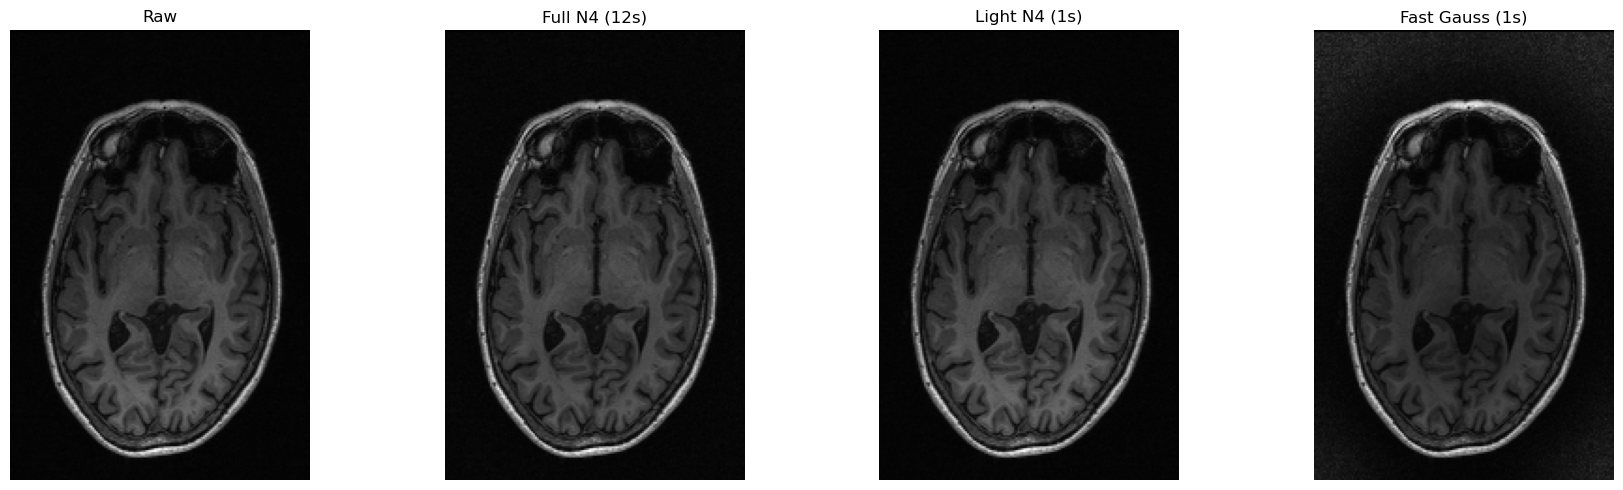

In [24]:
# STEP 2 — N4 BIAS FIELD CORRECTION
# Removes smooth intensity gradients caused by RF coil sensitivity and B1
# field non-uniformity. Replaces the Mayo B1+N3 corrections that were NOT
# applied to our scans (we verified this from image_description).

import time
from scipy.ndimage import gaussian_filter

# === Alternative 1: full N4 (current, slow, gold standard) ===
def n4_full(img):
    return ants.n4_bias_field_correction(img)

# === Alternative 2: lighter N4 (shrink=8, fewer iterations) ===
def n4_light(img):
    return ants.n4_bias_field_correction(
        img, shrink_factor=8,
        convergence={'iters': [30, 20], 'tol': 1e-4}
    )

# === Alternative 3: fast Gaussian-based bias correction ===
def fast_bias_correct(img, sigma=20):
    """Divide image by a heavily-smoothed version of itself."""
    arr = img.numpy()
    bias = gaussian_filter(arr, sigma=sigma)
    bias = np.clip(bias, np.percentile(bias[bias > 0], 5), None)
    corrected = arr / bias * arr.mean()
    return ants.from_numpy(
        corrected.astype(np.float32),
        origin=img.origin, spacing=img.spacing, direction=img.direction
    )

# === Run all 3 with timing ===
print("Running alternatives on one image...\n")

t0 = time.time(); img_full  = n4_full(img_raw);   t_full  = time.time() - t0
print(f"Full N4:    {t_full:6.1f} s")

t0 = time.time(); img_light = n4_light(img_raw);  t_light = time.time() - t0
print(f"Light N4:   {t_light:6.1f} s")

t0 = time.time(); img_fast  = fast_bias_correct(img_raw); t_fast = time.time() - t0
print(f"Fast Gauss: {t_fast:6.1f} s")

# === Visual comparison: 4 panels at the same axial slice ===
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
arrays = [img_raw.numpy(), img_full.numpy(), img_light.numpy(), img_fast.numpy()]
titles = [f"Raw",
          f"Full N4 ({t_full:.0f}s)",
          f"Light N4 ({t_light:.0f}s)",
          f"Fast Gauss ({t_fast:.0f}s)"]

z = arrays[0].shape[2] // 2
for ax, arr, ttl in zip(axes, arrays, titles):
    ax.imshow(arr[:, :, z].T, cmap="gray", origin="lower")
    ax.set_title(ttl)
    ax.axis("off")
plt.tight_layout(); plt.show()

### STEP 3: SKULL STRIPPING (HD-BET)

In [25]:
! pip install hd-bet --quiet


########################
If you are using hd-bet, please cite the following papers:

Isensee F, Schell M, Tursunova I, Brugnara G, Bonekamp D, Neuberger U, Wick A, Schlemmer HP, Heiland S, Wick W, Bendszus M, Maier-Hein KH, Kickingereder P. Automated brain extraction of multi-sequence MRI using artificial neural networks. arXiv preprint arXiv:1901.11341, 2019.

Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
########################



100%|██████████| 109M/109M [00:04<00:00, 26.6MB/s] 


There are 1 cases in the source folder
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 1 cases that I would like to predict

Predicting brain_bet.nii.gz:
perform_everything_on_device: True


100%|██████████| 10/10 [00:09<00:00,  1.03it/s]


sending off prediction to background worker for resampling and export
done with brain_bet.nii.gz


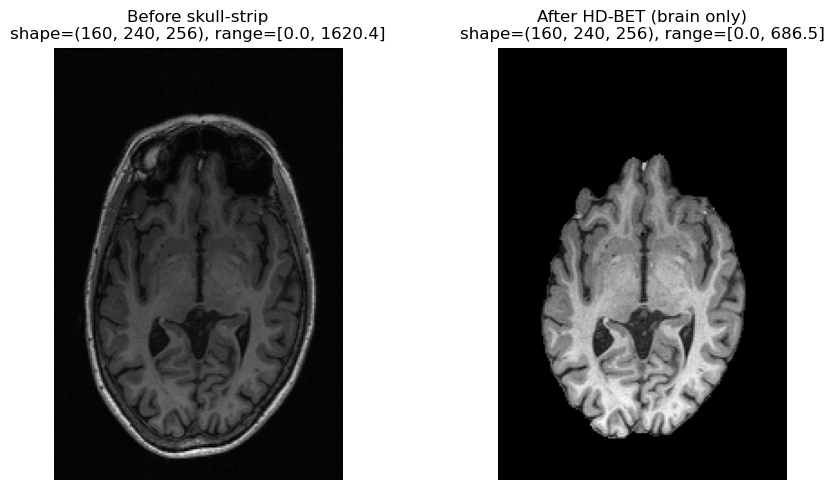

In [26]:
# STEP 3 — SKULL STRIPPING (HD-BET)
# Removes skull, scalp, eyes, neck. Keeps brain only.
# HD-BET is a deep-learning model trained on diverse MRIs - much more robust
# than classical methods like FSL BET, especially on heterogeneous ADNI data.

def skull_strip(img):
    """Run HD-BET via CLI. Returns (brain_image, brain_mask) as ANTs images."""
    with tempfile.TemporaryDirectory() as tmp:
        in_path  = Path(tmp) / "in.nii.gz"
        out_path = Path(tmp) / "brain.nii.gz"
        ants.image_write(img, str(in_path))
        subprocess.run(
            ["hd-bet",
             "-i", str(in_path),
             "-o", str(out_path),
             "-device", "cuda",       # single dash; valid torch device string
             "--save_bet_mask"],
            check=True
        )
        # Mask is saved as <output>_bet.nii.gz when --save_bet_mask is on
        mask_path = Path(tmp) / "brain_bet.nii.gz"
        if not mask_path.exists():
            mask_path = Path(tmp) / "brain_mask.nii.gz"  # fallback
        if not mask_path.exists():
            raise FileNotFoundError(f"HD-BET didn't produce a mask in {tmp}")
        brain = ants.image_read(str(out_path))
        mask  = ants.image_read(str(mask_path))
    return brain, mask

img_brain, brain_mask = skull_strip(img_light)
show_before_after(img_light, img_brain, "Before skull-strip", "After HD-BET (brain only)")

### STEP 4: AFFINE REGISTRATION TO MNI152 1mm

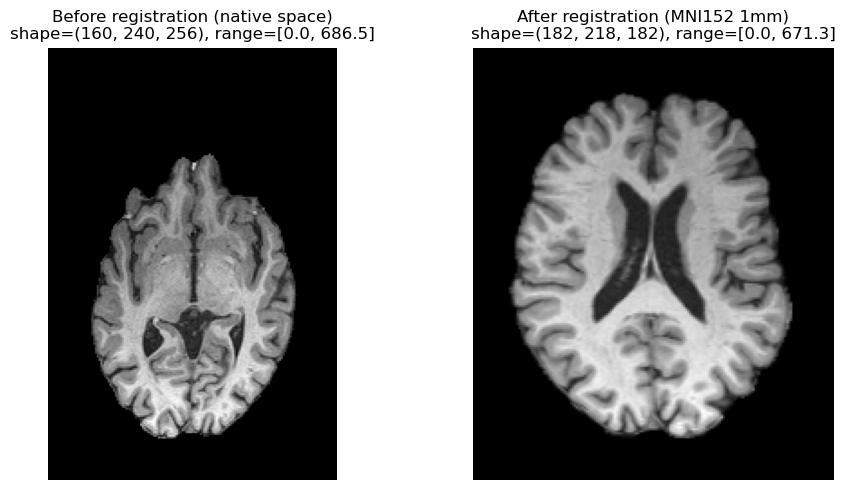

In [27]:
# STEP 4 — AFFINE REGISTRATION TO MNI152 1mm
# Aligns every brain to a common stereotactic space. After this, the
# hippocampus (and every other structure) sits at the same coordinates in
# every scan. This solves the "different slice counts / orientations" issue.
# We apply the same transform to the brain mask so it stays aligned.

def register_to_mni(brain, mask):
    reg = ants.registration(fixed=MNI, moving=brain, type_of_transform="Affine")
    brain_mni = reg["warpedmovout"]
    mask_mni  = ants.apply_transforms(
        fixed=MNI, moving=mask,
        transformlist=reg["fwdtransforms"],
        interpolator="nearestNeighbor",
    )
    return brain_mni, mask_mni

img_mni, mask_mni = register_to_mni(img_brain, brain_mask)
show_before_after(img_brain, img_mni, "Before registration (native space)",
                                       "After registration (MNI152 1mm)")

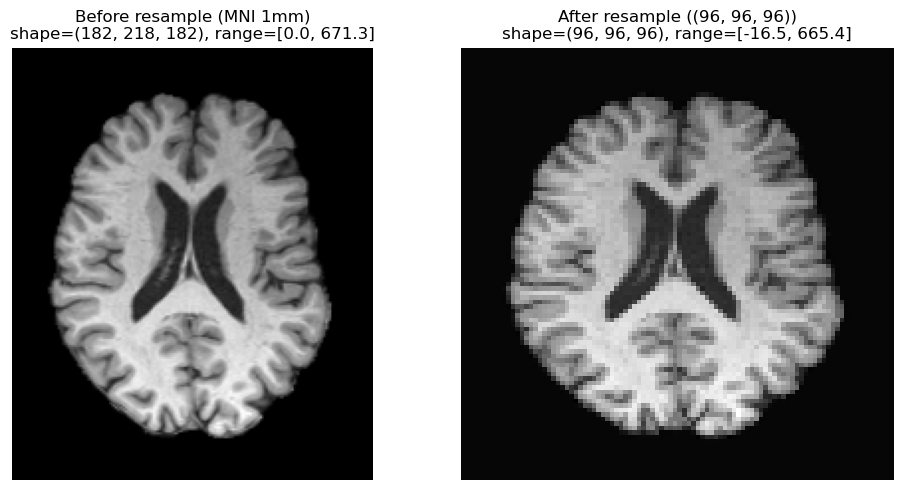

In [28]:
# STEP 5 — RESAMPLE TO 96^3
# Downsample from MNI 1mm (182x218x182) to a smaller cube to fit larger
# batches in GPU memory and speed up training. 96^3 keeps enough resolution
# to see hippocampal shape and cortical thinning. Mask uses nearest-neighbor.

def resample(img, shape=TARGET_SHAPE, is_mask=False):
    interp = 1 if is_mask else 4   # 1 = nearest-neighbor (mask), 4 = b-spline (image)
    return ants.resample_image(img, shape, use_voxels=True, interp_type=interp)

img_small  = resample(img_mni)
mask_small = resample(mask_mni, is_mask=True)
show_before_after(img_mni, img_small, "Before resample (MNI 1mm)",
                                      f"After resample ({TARGET_SHAPE})")

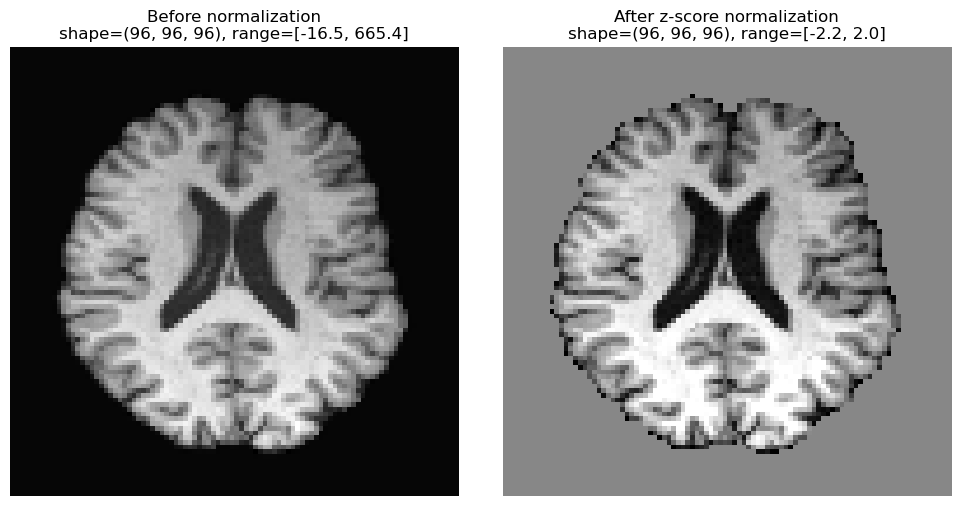

Brain voxels — mean=0.000, std=1.000


In [31]:
# STEP 6 — INTENSITY NORMALIZATION
# Make every scan have the same intensity distribution within the brain.
# Clip 1-99 percentile to remove extreme outliers, then z-score within the
# brain mask. The CNN now sees relative contrast (gray vs white vs CSF),
# not absolute scanner gain.

def normalize_intensity(img, mask):
    arr = img.numpy()
    m   = mask.numpy() > 0.5
    lo, hi = np.percentile(arr[m], [1, 99])         # robust intensity range
    arr = np.clip(arr, lo, hi)
    mean, std = arr[m].mean(), arr[m].std()
    arr = (arr - mean) / (std + 1e-8)               # z-score within brain
    arr = arr * m                                    # zero out non-brain voxels
    return arr.astype(np.float32)

img_norm = normalize_intensity(img_small, mask_small)
show_before_after(img_small.numpy(), img_norm,
                  "Before normalization", "After z-score normalization")
print(f"Brain voxels — mean={img_norm[mask_small.numpy()>0.5].mean():.3f}, "
      f"std={img_norm[mask_small.numpy()>0.5].std():.3f}")

In [35]:
# ============================================================
# PHASE 1 — N4 BIAS FIELD CORRECTION (parallel + light settings)
# ============================================================
# Light N4: shrink_factor=8, fewer iterations (~1.5s per scan, validated visually)
# 3 workers: safe for 16 GB RAM cap
# Logs each image as it finishes

import os
os.environ["ITK_GLOBAL_DEFAULT_NUMBER_OF_THREADS"] = "2"

from concurrent.futures import ProcessPoolExecutor
from functools import partial
from collections import Counter
import pandas as pd
from tqdm import tqdm

N_WORKERS = 6                  # safe for 16 GB pod; bump to 4-6 if RAM allows

N4_DIR = OUT_DIR / "n4_temp"
N4_DIR.mkdir(exist_ok=True)


def n4_one(image_id, nifti_dir, out_dir):
    """Light N4 on one image. Standalone for multiprocessing."""
    import ants
    from pathlib import Path

    out_path = Path(out_dir) / f"{image_id}.nii.gz"
    if out_path.exists():
        return image_id, "skipped"

    in_path = None
    for ext in [".nii", ".nii.gz"]:
        candidate = Path(nifti_dir) / f"{image_id}{ext}"
        if candidate.exists():
            in_path = candidate
            break
    if in_path is None:
        return image_id, "not_found"

    try:
        img = ants.image_read(str(in_path))
        img_n4 = ants.n4_bias_field_correction(
            img,
            shrink_factor=8,
            convergence={'iters': [30, 20], 'tol': 1e-4}
        )
        ants.image_write(img_n4, str(out_path))
        return image_id, "ok"
    except Exception as e:
        return image_id, f"fail: {type(e).__name__}: {e}"


# Run in parallel with progress bar + per-image print
ids = labels['image_id'].tolist()
results = []

with ProcessPoolExecutor(max_workers=N_WORKERS) as ex:
    fn = partial(n4_one, nifti_dir=str(NIFTI_DIR), out_dir=str(N4_DIR))
    pbar = tqdm(ex.map(fn, ids), total=len(ids), desc="N4 (parallel, light)")
    for image_id, status in pbar:
        results.append((image_id, status))
        pbar.set_postfix_str(f"{image_id}: {status}", refresh=False)

# Summary
status_counts = Counter(r[1].split(":")[0] for r in results)
print("\nN4 Phase 1 complete.")
print(status_counts)

pd.DataFrame(results, columns=["image_id", "status"]).to_csv(
    OUT_DIR / "n4_log.csv", index=False)

N4 (parallel, light): 100%|██████████| 2402/2402 [31:50<00:00,  1.26it/s, 1466185: ok] 


N4 Phase 1 complete.
Counter({'ok': 2402})


In [39]:
# ============================================================
# PHASES 2 + 3 — HD-BET + registration + resample + normalize
# ============================================================
# 34 GB RAM + 165 GB disk. Chunk size 200, no mid-run deletes.
# Logs to console AND to preprocessed/phase23.log
# Shows current image being processed + per-stage timing + ETA

import os, subprocess, shutil, logging, time
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import ants
from tqdm import tqdm

CHUNK_SIZE = 200
BRAIN_DIR  = OUT_DIR / "brain_temp"
LOG_FILE   = OUT_DIR / "phase23.log"


# ---------- logger setup ----------
logger = logging.getLogger("phase23")
logger.setLevel(logging.INFO)
logger.handlers.clear()

fmt = logging.Formatter("%(asctime)s [%(levelname)s] %(message)s",
                        datefmt="%H:%M:%S")
fh = logging.FileHandler(LOG_FILE, mode='a'); fh.setFormatter(fmt); logger.addHandler(fh)
sh = logging.StreamHandler();                  sh.setFormatter(fmt); logger.addHandler(sh)


def fmt_duration(seconds):
    """Format seconds as Xh Ym Zs."""
    h, rem = divmod(int(seconds), 3600)
    m, s = divmod(rem, 60)
    if h: return f"{h}h {m}m {s}s"
    if m: return f"{m}m {s}s"
    return f"{s}s"


logger.info("="*60)
logger.info("Phase 2+3 starting")
logger.info("="*60)


# ---------- step functions ----------
def register_to_mni(brain, mask):
    reg = ants.registration(fixed=MNI, moving=brain, type_of_transform="Affine")
    return reg["warpedmovout"], ants.apply_transforms(
        fixed=MNI, moving=mask,
        transformlist=reg["fwdtransforms"],
        interpolator="nearestNeighbor")

def resample(img, shape=TARGET_SHAPE, is_mask=False):
    return ants.resample_image(img, shape, use_voxels=True,
                                interp_type=1 if is_mask else 4)

def normalize_intensity(img, mask):
    arr = img.numpy(); m = mask.numpy() > 0.5
    lo, hi = np.percentile(arr[m], [1, 99])
    arr = np.clip(arr, lo, hi)
    arr = (arr - arr[m].mean()) / (arr[m].std() + 1e-8)
    return (arr * m).astype(np.float32)


# ---------- find which N4 files still need processing ----------
n4_files = sorted(N4_DIR.glob("*.nii.gz"))
todo = [f for f in n4_files
        if not (OUT_DIR / f"{f.stem.replace('.nii','')}.npy").exists()]
logger.info(f"N4 files: {len(n4_files)} | Already finalized: {len(n4_files) - len(todo)} | To do: {len(todo)}")


# ---------- per-chunk worker ----------
def process_chunk(chunk_idx, n_chunks_total, n4_paths):
    log = []
    chunk_t0 = time.time()
    logger.info(f"=== Chunk {chunk_idx}/{n_chunks_total} — {len(n4_paths)} images ===")

    if BRAIN_DIR.exists(): shutil.rmtree(BRAIN_DIR)
    BRAIN_DIR.mkdir()

    # Stage files
    t0 = time.time()
    stage = BRAIN_DIR / "_in"; stage.mkdir()
    for f in n4_paths:
        shutil.copy(f, stage / f.name)
    logger.info(f"  [stage]   copied {len(n4_paths)} files in {fmt_duration(time.time()-t0)}")

    # Phase 2: HD-BET batch
    t0 = time.time()
    try:
        subprocess.run(
            ["hd-bet",
             "-i", str(stage), "-o", str(BRAIN_DIR),
             "-device", "cuda",
             "--save_bet_mask", "--disable_tta"],
            check=True, capture_output=True)
        hdbet_time = time.time() - t0
        logger.info(f"  [hd-bet]  done in {fmt_duration(hdbet_time)} "
                    f"({hdbet_time/len(n4_paths):.1f}s per image)")
    except subprocess.CalledProcessError as e:
        logger.error(f"  [hd-bet]  FAILED (returncode={e.returncode})")
        logger.error(f"  stderr: {e.stderr.decode()[:500]}")
        for f in n4_paths:
            log.append((f.stem.replace('.nii',''), f"fail hdbet: {e.returncode}"))
        return log
    finally:
        shutil.rmtree(stage)

    # Phase 3: register + resample + normalize + save
    t0 = time.time()
    pbar = tqdm(n4_paths, desc=f"  [reg+save] chunk {chunk_idx}", leave=False)
    for f in pbar:
        image_id = f.stem.replace('.nii','')
        pbar.set_postfix_str(f"current: {image_id}")
        try:
            brain_path = BRAIN_DIR / f"{image_id}.nii.gz"
            mask_path  = BRAIN_DIR / f"{image_id}_bet.nii.gz"
            if not (brain_path.exists() and mask_path.exists()):
                logger.warning(f"  {image_id}: HD-BET output missing")
                log.append((image_id, "fail: hdbet output missing")); continue

            brain = ants.image_read(str(brain_path))
            mask  = ants.image_read(str(mask_path))
            brain_mni, mask_mni = register_to_mni(brain, mask)
            brain_small = resample(brain_mni)
            mask_small  = resample(mask_mni, is_mask=True)
            arr_norm    = normalize_intensity(brain_small, mask_small)

            np.save(OUT_DIR / f"{image_id}.npy",      arr_norm.astype(np.float16))
            np.save(OUT_DIR / f"{image_id}_mask.npy",
                    (mask_small.numpy() > 0.5).astype(np.uint8))
            log.append((image_id, "ok"))
        except Exception as e:
            logger.error(f"  {image_id}: {type(e).__name__}: {e}")
            log.append((image_id, f"fail reg: {type(e).__name__}"))

    reg_time = time.time() - t0
    logger.info(f"  [reg+save] done in {fmt_duration(reg_time)} "
                f"({reg_time/len(n4_paths):.1f}s per image)")
    shutil.rmtree(BRAIN_DIR)

    # Chunk summary
    statuses = Counter(s.split(":")[0] for _, s in log)
    chunk_total = time.time() - chunk_t0
    logger.info(f"  ✓ Chunk {chunk_idx} done in {fmt_duration(chunk_total)} | {dict(statuses)}")
    return log


# ---------- main loop ----------
full_log = []
n_chunks = (len(todo) - 1) // CHUNK_SIZE + 1 if todo else 0
overall_t0 = time.time()

logger.info(f"Will process {len(todo)} images in {n_chunks} chunks of {CHUNK_SIZE}")

for start in range(0, len(todo), CHUNK_SIZE):
    chunk = todo[start : start + CHUNK_SIZE]
    chunk_idx = start // CHUNK_SIZE + 1
    log = process_chunk(chunk_idx, n_chunks, chunk)
    full_log.extend(log)

    pd.DataFrame(log, columns=["image_id", "status"]).to_csv(
        OUT_DIR / "phase23_log.csv",
        mode='a',
        header=not (OUT_DIR / "phase23_log.csv").exists(),
        index=False)

    # Overall progress + ETA
    statuses = Counter(s.split(":")[0] for _, s in full_log)
    n_done = len(list(OUT_DIR.glob('*[0-9].npy')))
    elapsed = time.time() - overall_t0
    avg_per_chunk = elapsed / chunk_idx
    eta = avg_per_chunk * (n_chunks - chunk_idx)
    pct = 100 * chunk_idx / n_chunks

    logger.info(
        f"  📊 Overall: {n_done}/{len(todo)} done ({pct:.0f}%) | "
        f"{dict(statuses)} | "
        f"elapsed {fmt_duration(elapsed)} | "
        f"ETA {fmt_duration(eta)}"
    )
    logger.info("")  # blank line for readability


# ---------- final cleanup + summary ----------
if BRAIN_DIR.exists(): shutil.rmtree(BRAIN_DIR)
n_final = len(list(OUT_DIR.glob('*[0-9].npy')))
total = time.time() - overall_t0

logger.info("="*60)
logger.info(f"✓ COMPLETE — {n_final} preprocessed images in {fmt_duration(total)}")
logger.info(f"Final: {dict(Counter(s.split(':')[0] for _, s in full_log))}")
logger.info("="*60)

17:35:49 [INFO] ============================================================
17:35:49 [INFO] Phase 2+3 starting
17:35:49 [INFO] ============================================================
17:35:49 [INFO] N4 files: 2402 | Already finalized: 0 | To do: 2402
17:35:49 [INFO] Will process 2402 images in 13 chunks of 200
17:35:49 [INFO] === Chunk 1/13 — 200 images ===
17:35:57 [INFO]   [stage]   copied 200 files in 7s
17:43:16 [INFO]   [hd-bet]  done in 7m 19s (2.2s per image)
18:05:16 [INFO]   [reg+save] done in 21m 58s (6.6s per image)                             
18:05:16 [INFO]   ✓ Chunk 1 done in 29m 26s | {'ok': 200}
18:05:16 [INFO]   📊 Overall: 200/2402 done (8%) | {'ok': 200} | elapsed 29m 26s | ETA 5h 53m 15s
18:05:16 [INFO] 
18:05:16 [INFO] === Chunk 2/13 — 200 images ===
18:06:14 [INFO]   [stage]   copied 200 files in 57s
18:14:00 [INFO]   [hd-bet]  done in 7m 46s (2.3s per image)
18:35:50 [INFO]   [reg+save] done in 21m 49s (6.5s per image)                             
18:35:51 

In [40]:
print('hell')

hell


In [41]:
final_files = list(OUT_DIR.glob('*[0-9].npy'))
mask_files  = list(OUT_DIR.glob('*_mask.npy'))
print(f"Preprocessed images: {len(final_files)}")
print(f"Brain masks:         {len(mask_files)}")
print(f"Expected:            {len(labels)} of each")

Preprocessed images: 2402
Brain masks:         2402
Expected:            2402 of each


In [43]:
log_df = pd.read_csv(OUT_DIR / "phase23_log.csv")
print(f"Total log entries: {len(log_df)}\n")
print("Status breakdown:")
print(log_df['status'].value_counts())

Total log entries: 2402

Status breakdown:
status
ok    2402
Name: count, dtype: int64


In [44]:
fails = log_df[log_df['status'] != 'ok']
print(f"Failures: {len(fails)}")
if len(fails) > 0:
    print(fails['status'].value_counts())
    print("\nSample fails:")
    print(fails.head(10))

Failures: 0


Image: shape=(96, 96, 96), dtype=float16
  min=-2.41, max=1.69, mean=-0.00
Mask:  shape=(96, 96, 96), dtype=uint8, brain voxels=221471


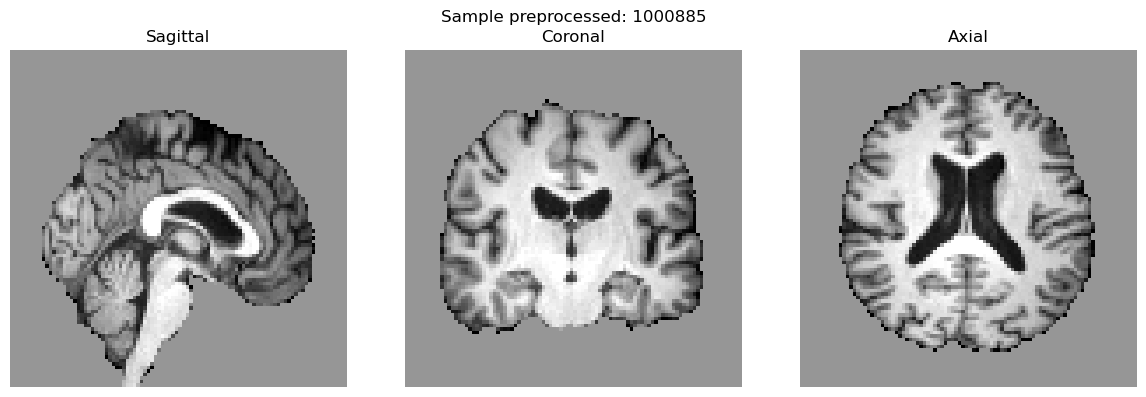

In [45]:
import numpy as np
import matplotlib.pyplot as plt

sample_id = log_df[log_df['status']=='ok']['image_id'].iloc[0]
arr  = np.load(OUT_DIR / f"{sample_id}.npy")
mask = np.load(OUT_DIR / f"{sample_id}_mask.npy")

print(f"Image: shape={arr.shape}, dtype={arr.dtype}")
print(f"  min={arr.min():.2f}, max={arr.max():.2f}, mean={arr.mean():.2f}")
print(f"Mask:  shape={mask.shape}, dtype={mask.dtype}, brain voxels={mask.sum()}")

# Visual: 3 orthogonal views
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(arr[arr.shape[0]//2, :, :].T, cmap='gray', origin='lower'); axes[0].set_title("Sagittal")
axes[1].imshow(arr[:, arr.shape[1]//2, :].T, cmap='gray', origin='lower'); axes[1].set_title("Coronal")
axes[2].imshow(arr[:, :, arr.shape[2]//2].T, cmap='gray', origin='lower'); axes[2].set_title("Axial")
for ax in axes: ax.axis("off")
fig.suptitle(f"Sample preprocessed: {sample_id}")
plt.tight_layout(); plt.show()

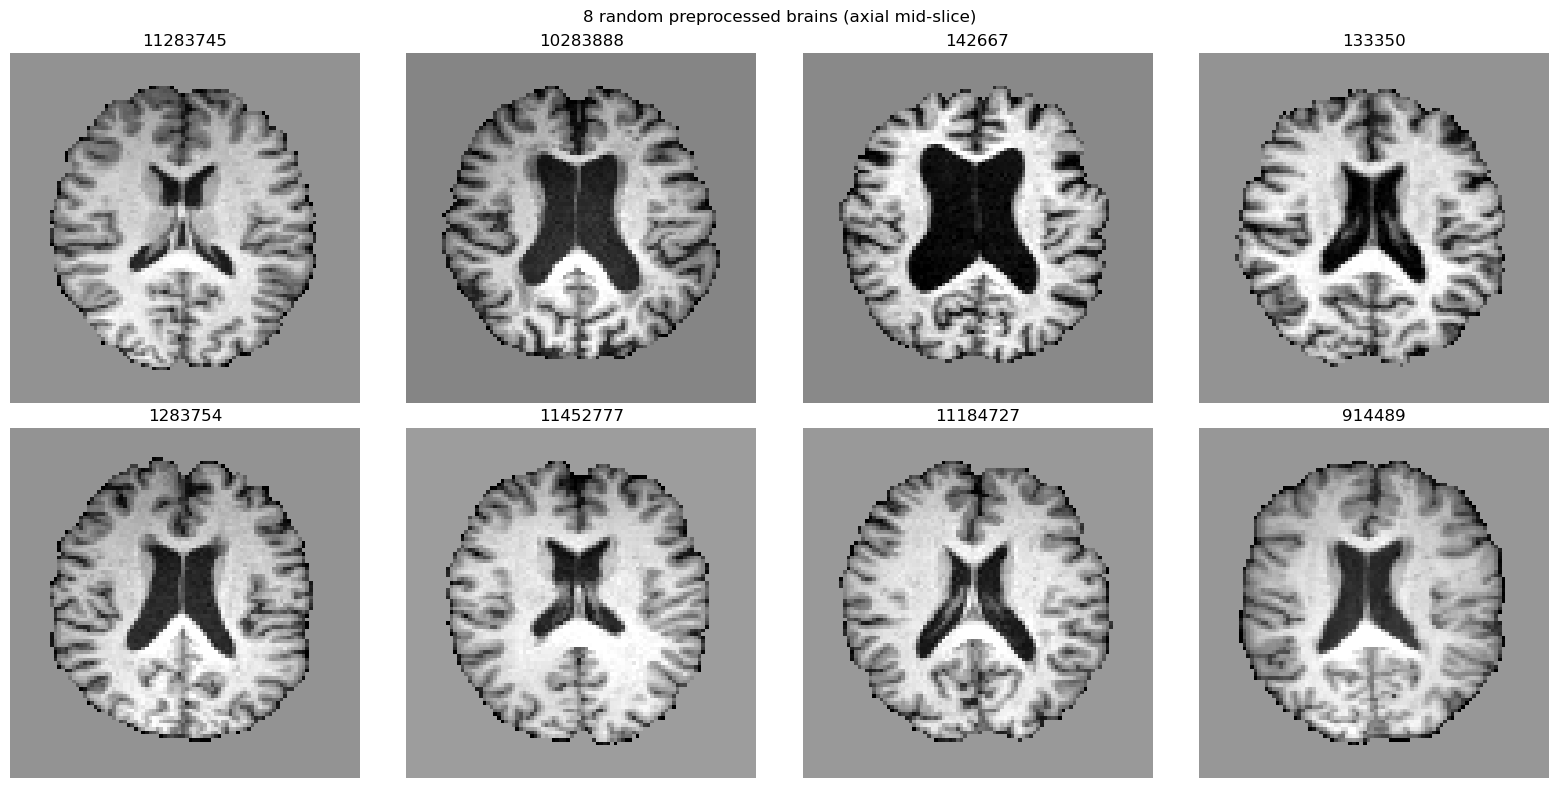

In [46]:
import random

ok_ids = log_df[log_df['status']=='ok']['image_id'].tolist()
random.seed(42)
samples = random.sample(ok_ids, 8)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, image_id in zip(axes.flat, samples):
    arr = np.load(OUT_DIR / f"{image_id}.npy")
    ax.imshow(arr[:, :, 48].T, cmap='gray', origin='lower')
    ax.set_title(f"{image_id}")
    ax.axis("off")
fig.suptitle("8 random preprocessed brains (axial mid-slice)")
plt.tight_layout(); plt.show()

In [47]:
sample_ids = random.sample(ok_ids, 50)
all_means, all_stds, all_brain_voxels = [], [], []

for image_id in sample_ids:
    arr  = np.load(OUT_DIR / f"{image_id}.npy")
    mask = np.load(OUT_DIR / f"{image_id}_mask.npy") > 0
    all_means.append(arr[mask].mean())
    all_stds.append(arr[mask].std())
    all_brain_voxels.append(mask.sum())

print(f"Brain mean intensity:  {np.mean(all_means):.3f} (target: ~0)")
print(f"Brain std intensity:   {np.mean(all_stds):.3f}  (target: ~1)")
print(f"Brain voxels (typical): {np.median(all_brain_voxels):.0f}")
print(f"Brain voxels (range):   {np.min(all_brain_voxels)}-{np.max(all_brain_voxels)}")

/opt/conda/lib/python3.11/site-packages/numpy/core/_methods.py:187: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


Brain mean intensity:  -0.000 (target: ~0)
Brain std intensity:   inf  (target: ~1)
Brain voxels (typical): 220952
Brain voxels (range):   212492-229157


In [48]:
import os
preprocessed_size = sum(f.stat().st_size for f in OUT_DIR.rglob('*.npy')) / 1e9
print(f"Total .npy size: {preprocessed_size:.1f} GB")

stat = os.statvfs(OUT_DIR)
print(f"Free disk: {stat.f_bavail * stat.f_frsize / 1e9:.1f} GB")

Total .npy size: 6.4 GB
Free disk: 86.6 GB


In [49]:
ok_ids_set = set(log_df[log_df['status']=='ok']['image_id'])
labels_clean = labels[labels['image_id'].isin(ok_ids_set)].reset_index(drop=True)
print(f"Original labels: {len(labels)}")
print(f"Labels with successful preprocessing: {len(labels_clean)}")

# Save the cleaned labels for CNN training
labels_clean.to_csv(OUT_DIR / "labels_preprocessed.csv", index=False)
print(f"Saved to {OUT_DIR / 'labels_preprocessed.csv'}")

Original labels: 2402
Labels with successful preprocessing: 2402
Saved to images/MRI_preprocessed/labels_preprocessed.csv


image_id: 1673575
Image: shape=(96, 96, 96), dtype=float16, range=[-1.98, 1.83]
Mask:  shape=(96, 96, 96), dtype=uint8, brain voxels=224326/884736 (25.4%)


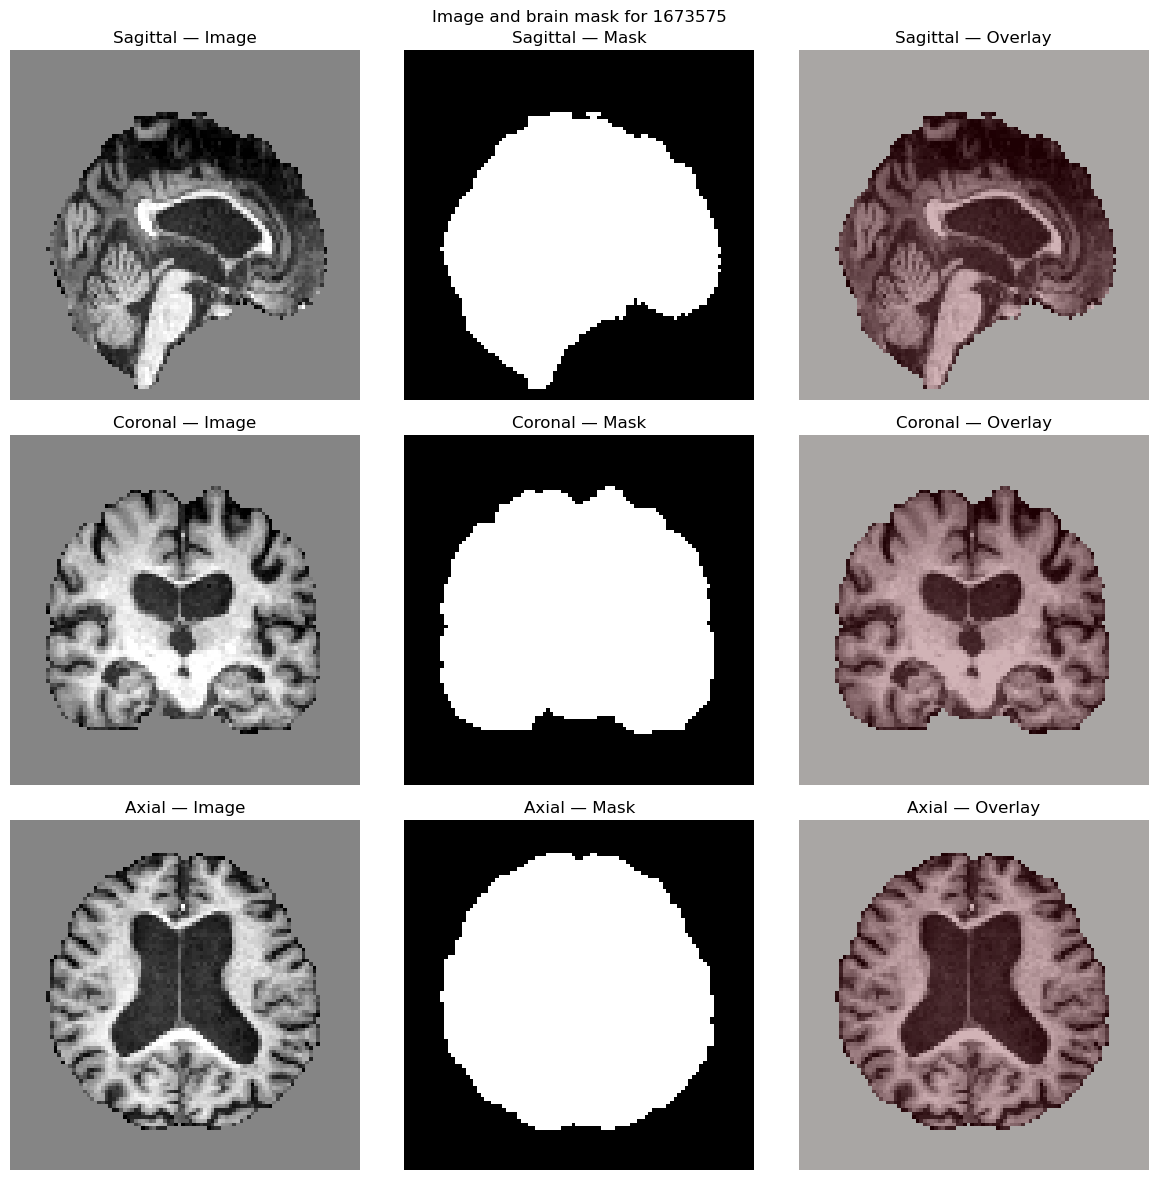

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Pick a random successfully-preprocessed image
ok_ids = log_df[log_df['status']=='ok']['image_id'].tolist()
sample_id = random.choice(ok_ids)

# Load image and mask
arr  = np.load(OUT_DIR / f"{sample_id}.npy")
mask = np.load(OUT_DIR / f"{sample_id}_mask.npy")

print(f"image_id: {sample_id}")
print(f"Image: shape={arr.shape}, dtype={arr.dtype}, range=[{arr.min():.2f}, {arr.max():.2f}]")
print(f"Mask:  shape={mask.shape}, dtype={mask.dtype}, brain voxels={mask.sum()}/{mask.size} ({100*mask.sum()/mask.size:.1f}%)")

# 3 orthogonal views: image, mask, overlay
mid_x, mid_y, mid_z = [s // 2 for s in arr.shape]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

views = [
    ("Sagittal", arr[mid_x, :, :], mask[mid_x, :, :]),
    ("Coronal",  arr[:, mid_y, :], mask[:, mid_y, :]),
    ("Axial",    arr[:, :, mid_z], mask[:, :, mid_z]),
]

for row, (view_name, img_slice, mask_slice) in enumerate(views):
    # Image
    axes[row, 0].imshow(img_slice.T, cmap='gray', origin='lower')
    axes[row, 0].set_title(f"{view_name} — Image")
    
    # Mask
    axes[row, 1].imshow(mask_slice.T, cmap='gray', origin='lower')
    axes[row, 1].set_title(f"{view_name} — Mask")
    
    # Overlay (image with mask in red, semi-transparent)
    axes[row, 2].imshow(img_slice.T, cmap='gray', origin='lower')
    axes[row, 2].imshow(mask_slice.T, cmap='Reds', origin='lower', alpha=0.3)
    axes[row, 2].set_title(f"{view_name} — Overlay")
    
    for ax in axes[row]: ax.axis("off")

plt.suptitle(f"Image and brain mask for {sample_id}", y=0.98)
plt.tight_layout()
plt.show()